# 04 -- Abuse-Ring Sentinel

A **second, independent detector**, not a feature bolted onto the
return-risk scorer. It answers a different question: *"is this cluster of
accounts sharing device/address/payment fingerprints a coordinated abuse
ring, or just benign sharing (e.g. a family at one address)?"*

Pipeline: build a graph over customers (edge = shared device/payment/
address fingerprint) -> take connected components as candidate clusters ->
engineer cluster-level features -> train a classifier on cluster-level
ground truth.

See notebook 01 for the first bug we caught here (benign vs. ring
identifier-sharing being mutually exclusive by construction, made trivially
separable). This notebook covers the second bug: a degenerate bootstrap
confidence interval.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
print(f"Customers: {len(customers)} | Orders: {len(orders)}")

Customers: 6000 | Orders: 50108


## Per-customer behavior aggregates (whole-history, not rolling)

Unlike the return-risk model's *rolling* features (which must only see the past to avoid leakage on a per-order timeline), this profiles an account as a static entity -- a whole-history summary is the right unit here, not a point-in-time snapshot.

In [2]:
cust_agg = orders.groupby("customer_id").agg(
    total_orders=("order_id", "count"),
    total_returns=("is_returned", "sum"),
    total_abusive_returns=("is_abusive_return", "sum"),
).reset_index()
cust_agg["return_rate"] = cust_agg["total_returns"] / cust_agg["total_orders"]
cust_agg["abusive_return_rate"] = np.where(
    cust_agg["total_returns"] > 0, cust_agg["total_abusive_returns"] / cust_agg["total_returns"], 0.0
)
cust_agg.head()

,customer_id,total_orders,total_returns,total_abusive_returns,return_rate,abusive_return_rate
0,CUST100000,10,3,0,0.3,0.0
1,CUST100001,4,2,0,0.5,0.0
2,CUST100002,1,0,0,0.0,0.0
3,CUST100003,1,0,0,0.0,0.0
4,CUST100004,10,3,0,0.3,0.0


## Build the identifier-sharing graph and extract clusters

In [3]:
def build_graph(customers):
    G = nx.Graph()
    G.add_nodes_from(customers["customer_id"])
    for col, edge_type in [("device_fingerprint", "device"), ("payment_fingerprint", "payment"),
                            ("address_fingerprint", "address")]:
        for members in customers.groupby(col)["customer_id"].apply(list):
            if len(members) < 2:
                continue
            for i in range(len(members)):
                for j in range(i + 1, len(members)):
                    if G.has_edge(members[i], members[j]):
                        G[members[i]][members[j]]["shared"].add(edge_type)
                    else:
                        G.add_edge(members[i], members[j], shared={edge_type})
    return G

G = build_graph(customers)

cust_lookup = customers.set_index("customer_id")
agg_lookup = cust_agg.set_index("customer_id")
rows = []
for members in nx.connected_components(G):
    if len(members) < 2:
        continue
    members = list(members)
    sub = cust_lookup.loc[members]
    edge_types = set()
    for u, v, data in G.subgraph(members).edges(data=True):
        edge_types |= data["shared"]
    member_agg = agg_lookup.reindex(members).fillna(0.0)
    rows.append({
        "size": len(members),
        "shares_device": int("device" in edge_types),
        "shares_payment": int("payment" in edge_types),
        "shares_address": int("address" in edge_types),
        "shares_device_and_payment": int({"device", "payment"}.issubset(edge_types)),
        "avg_account_age": sub["account_age_days"].mean(),
        "account_age_std": sub["account_age_days"].std() if len(sub) > 1 else 0.0,
        "avg_return_rate": member_agg["return_rate"].mean(),
        "max_return_rate": member_agg["return_rate"].max(),
        "avg_abusive_return_rate": member_agg["abusive_return_rate"].mean(),
        "max_abusive_return_rate": member_agg["abusive_return_rate"].max(),
        "avg_total_orders": member_agg["total_orders"].mean(),
        "is_true_ring": int(sub["ring_id"].notna().any()),
    })
clusters = pd.DataFrame(rows)
print(f"Total clusters: {len(clusters)} | true rings: {clusters['is_true_ring'].sum()} | "
      f"benign sharing: {(clusters['is_true_ring']==0).sum()}")
clusters.head()

Total clusters: 176 | true rings: 48 | benign sharing: 128


,size,shares_device,shares_payment,shares_address,shares_device_and_payment,avg_account_age,account_age_std,avg_return_rate,max_return_rate,avg_abusive_return_rate,max_abusive_return_rate,avg_total_orders,is_true_ring
0,3,0,0,1,0,633.000000,260.501440,0.166667,0.300000,0.333333,1.0,5.666667,0
1,9,1,1,0,1,799.111111,319.290011,0.289506,0.800000,0.138889,0.5,8.222222,1
2,3,0,0,1,0,1299.666667,143.113009,0.183761,0.307692,0.000000,0.0,12.666667,0
3,6,1,1,0,1,899.166667,563.170105,0.290963,0.428571,0.342593,1.0,9.666667,1
4,3,0,1,1,0,727.666667,189.964032,0.194444,0.250000,0.000000,0.0,10.000000,0


## Train/test split and classifier

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc, confusion_matrix,
    classification_report, average_precision_score,
)

FEATURE_COLS = [
    "size", "shares_device", "shares_payment", "shares_address",
    "shares_device_and_payment", "avg_account_age", "account_age_std",
    "avg_return_rate", "max_return_rate", "avg_abusive_return_rate",
    "max_abusive_return_rate", "avg_total_orders",
]
X = clusters[FEATURE_COLS]
y = clusters["is_true_ring"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Train clusters: {len(X_train)} | Test clusters: {len(X_test)}")

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, proba)
print(f"ROC-AUC: {auc(fpr, tpr):.3f} | Average Precision: {average_precision_score(y_test, proba):.3f}")
print()
print("CAVEAT: with only ~50 test clusters, AUC/AP near the extremes are easy")
print("to hit by chance -- read as indicative, not as a guarantee that real-world")
print("rings separate this cleanly (real rings also actively adapt to evade")
print("known signals, unlike this static synthetic set).")

Train clusters: 123 | Test clusters: 53
ROC-AUC: 1.000 | Average Precision: 1.000

CAVEAT: with only ~50 test clusters, AUC/AP near the extremes are easy
to hit by chance -- read as indicative, not as a guarantee that real-world
rings separate this cleanly (real rings also actively adapt to evade
known signals, unlike this static synthetic set).


Deployed threshold (best F1 on held-out set): 0.271
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        39
           1      1.000     1.000     1.000        14

    accuracy                          1.000        53
   macro avg      1.000     1.000     1.000        53
weighted avg      1.000     1.000     1.000        53



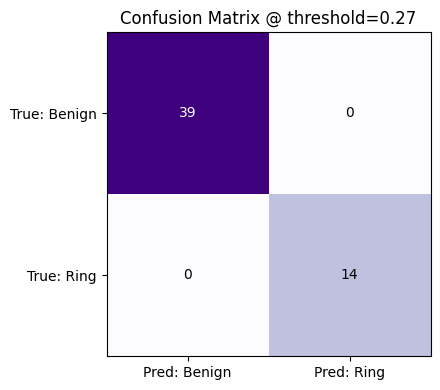

In [5]:
precision, recall, pr_thresh = precision_recall_curve(y_test, proba)
f1_scores = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall + 1e-9), 0)
best_idx = np.argmax(f1_scores[:-1])
deployed_threshold = float(pr_thresh[best_idx])
preds = (proba >= deployed_threshold).astype(int)

print(f"Deployed threshold (best F1 on held-out set): {deployed_threshold:.3f}")
print(classification_report(y_test, preds, digits=3))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Purples")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
plt.xticks([0, 1], ["Pred: Benign", "Pred: Ring"]); plt.yticks([0, 1], ["True: Benign", "True: Ring"])
plt.title(f"Confusion Matrix @ threshold={deployed_threshold:.2f}")
plt.tight_layout(); plt.show()

## What broke: a degenerate bootstrap confidence interval

With only ~50 test clusters, we wanted an honest sense of how much to
trust the precision/recall numbers -- so we bootstrapped: resample the
test set with replacement 2000 times, recompute the metric each time,
report the 2.5th/97.5th percentiles.

The result came back `[1.000, 1.000]` -- a perfectly tight interval. That
looked suspicious, and it was: **bootstrap-resampling a fixed test set
that happens to have zero errors can never introduce a new error**, no
matter how many times you resample it -- you're just duplicating already-
correct predictions in different proportions. The interval was measuring
"did this exact set of 50 points contain any mistakes" (no), not "how much
would this vary on a different sample of clusters" -- which is the
question we actually wanted answered.

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

rng = np.random.default_rng(42)
y_test_arr = y_test.values
boot_recall = []
for _ in range(1000):
    idx = rng.integers(0, len(y_test_arr), size=len(y_test_arr))
    yt, yp = y_test_arr[idx], preds[idx]
    if yt.sum() == 0 or yp.sum() == 0:
        continue
    boot_recall.append(recall_score(yt, yp, zero_division=0))

print(f"Naive bootstrap recall CI: [{np.percentile(boot_recall, 2.5):.3f}, {np.percentile(boot_recall, 97.5):.3f}]")
print("-- degenerate, exactly as expected: resampling zero errors can't create new ones.")

Naive bootstrap recall CI: [1.000, 1.000]
-- degenerate, exactly as expected: resampling zero errors can't create new ones.


### The fix: repeated random train/test splits

The informative version of "how much can we trust this number" for a
small dataset varies *which clusters the model has never seen*, across
many different splits -- not just resampling one fixed split.

In [7]:
n_repeats = 200
rep_recall = []
for i in range(n_repeats):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1000 + i, stratify=y)
    c = LogisticRegression(max_iter=1000, class_weight="balanced")
    c.fit(Xtr, ytr)
    p = c.predict_proba(Xte)[:, 1]
    pr = (p >= deployed_threshold).astype(int)
    if yte.sum() == 0 or pr.sum() == 0:
        continue
    rep_recall.append(recall_score(yte, pr, zero_division=0))

print(f"Repeated-split recall: mean={np.mean(rep_recall):.3f}, "
      f"[2.5-97.5 pct: {np.percentile(rep_recall, 2.5):.3f} - {np.percentile(rep_recall, 97.5):.3f}]")
print(f"(n={len(rep_recall)} repeats)")
print()
print("A genuinely informative interval: recall varies meaningfully depending")
print("on which clusters land in the test set, reflecting real small-sample")
print("uncertainty instead of a fake tight bound.")

Repeated-split recall: mean=0.997, [2.5-97.5 pct: 0.929 - 1.000]
(n=200 repeats)

A genuinely informative interval: recall varies meaningfully depending
on which clusters land in the test set, reflecting real small-sample
uncertainty instead of a fake tight bound.


## Save the deployed ring detector

In [8]:
import joblib, json

joblib.dump(clf, "model/ring_detector_model.pkl")
clusters.to_csv("model/abuse_ring_clusters.csv", index=False)
with open("model/ring_detector_config.json", "w") as f:
    json.dump({
        "feature_columns": FEATURE_COLS,
        "target": "is_true_ring",
        "roc_auc": float(auc(fpr, tpr)),
        "avg_precision": float(average_precision_score(y_test, proba)),
        "deployed_threshold": deployed_threshold,
        "threshold_selection": "best F1 on held-out test set",
        "note": "Small sample size (~176 clusters, ~50 in test); treat metrics as "
                "indicative. See the repeated-split analysis above for the honest "
                "version of the confidence interval question.",
    }, f, indent=2)
print("Saved model/ring_detector_model.pkl, model/ring_detector_config.json, "
      "model/abuse_ring_clusters.csv")

Saved model/ring_detector_model.pkl, model/ring_detector_config.json, model/abuse_ring_clusters.csv
